# 1. Importing modules and functions

In [1]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from molvs import standardize_smiles
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import permutation_test_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn import metrics
from sklearn.metrics import pairwise_distances
import joblib
import pickle
from numpy import savetxt
from padelpy import from_sdf
import shap
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import warnings
from catboost import CatBoostRegressor
warnings.filterwarnings('ignore')

In [2]:
import glob
xml_files = glob.glob("fingerprints_xml/*.xml")
xml_files.sort()
xml_files

['fingerprints_xml\\AtomPairs2DFingerprintCount.xml',
 'fingerprints_xml\\AtomPairs2DFingerprinter.xml',
 'fingerprints_xml\\EStateFingerprinter.xml',
 'fingerprints_xml\\ExtendedFingerprinter.xml',
 'fingerprints_xml\\Fingerprinter.xml',
 'fingerprints_xml\\GraphOnlyFingerprinter.xml',
 'fingerprints_xml\\KlekotaRothFingerprintCount.xml',
 'fingerprints_xml\\KlekotaRothFingerprinter.xml',
 'fingerprints_xml\\MACCSFingerprinter.xml',
 'fingerprints_xml\\PubchemFingerprinter.xml',
 'fingerprints_xml\\SubstructureFingerprintCount.xml',
 'fingerprints_xml\\SubstructureFingerprinter.xml']

In [3]:
FP_list = ['AtomPairs2DCount',
 'AtomPairs2D',
 'EState',
 'CDKextended',
 'CDK',
 'CDKgraphonly',
 'KlekotaRothCount',
 'KlekotaRoth',
 'MACCS',
 'PubChem',
 'SubstructureCount',
 'Substructure']

In [4]:
fp = dict(zip(FP_list, xml_files))
fp

{'AtomPairs2DCount': 'fingerprints_xml\\AtomPairs2DFingerprintCount.xml',
 'AtomPairs2D': 'fingerprints_xml\\AtomPairs2DFingerprinter.xml',
 'EState': 'fingerprints_xml\\EStateFingerprinter.xml',
 'CDKextended': 'fingerprints_xml\\ExtendedFingerprinter.xml',
 'CDK': 'fingerprints_xml\\Fingerprinter.xml',
 'CDKgraphonly': 'fingerprints_xml\\GraphOnlyFingerprinter.xml',
 'KlekotaRothCount': 'fingerprints_xml\\KlekotaRothFingerprintCount.xml',
 'KlekotaRoth': 'fingerprints_xml\\KlekotaRothFingerprinter.xml',
 'MACCS': 'fingerprints_xml\\MACCSFingerprinter.xml',
 'PubChem': 'fingerprints_xml\\PubchemFingerprinter.xml',
 'SubstructureCount': 'fingerprints_xml\\SubstructureFingerprintCount.xml',
 'Substructure': 'fingerprints_xml\\SubstructureFingerprinter.xml'}

# 2.Data entry and curation work set

In [5]:
uploaded_file_ws="datasets/HDAC8_work.sdf"
supplier_ws = Chem.ForwardSDMolSupplier(uploaded_file_ws,sanitize=False)
failed_mols_ws = []
all_mols_ws =[]
wrong_structure_ws=[]
wrong_smiles_ws=[]
y_tr = []
y_bad_index=[]

for i, m in enumerate(supplier_ws):
    structure = Chem.Mol(m)
    all_mols_ws.append(structure)
    y_tr.append(m.GetProp("pchembl_value_mean"))
    try:
        Chem.SanitizeMol(structure)
    except:
        failed_mols_ws.append(m)
        wrong_smiles_ws.append(Chem.MolToSmiles(m))
        wrong_structure_ws.append(str(i+1))
        y_bad_index.append(i)
print('Original data: ', len(all_mols_ws), 'molecules')
print('Failed data: ', len(failed_mols_ws), 'molecules')
number_ws =[]
for i in range(len(failed_mols_ws)):
        number_ws.append(str(i+1))
bad_molecules_ws = pd.DataFrame({'No. failed molecule in original set': wrong_structure_ws, 'SMILES of wrong structure: ': wrong_smiles_ws, 'No.': number_ws}, index=None)
bad_molecules_ws = bad_molecules_ws.set_index('No.')
bad_molecules_ws

Original data:  2210 molecules
Failed data:  0 molecules


,No. failed molecule in original set,SMILES of wrong structure:
No.,,


deleting activity values for substances with incorrect structure

In [6]:
y_tr[:] = [x for i,x in enumerate(y_tr) if i not in y_bad_index]

In [7]:
len(y_tr)

2210

# 3.Standardization SDF file for work set

In [8]:
all_mols_ws[:] = [x for i,x in enumerate(all_mols_ws) if i not in y_bad_index] 
records = []
for i in range(len(all_mols_ws)):
    record = Chem.MolToSmiles(all_mols_ws[i])
    records.append(record)

moldf_ws = []
for i,record in enumerate(records):
    standard_record = standardize_smiles(record)
    m = Chem.MolFromSmiles(standard_record)
    moldf_ws.append(m)
    
print('Kept data: ', len(moldf_ws), 'molecules')

Kept data:  2210 molecules


In [9]:
records_ws = []
for i in range(len(moldf_ws)):
    record = Chem.MolToSmiles(moldf_ws[i])
    records_ws.append(record)

In [10]:
df = pd.DataFrame(records_ws, columns=["Smiles"])
df.to_csv('datasets/molecule_ws.smi', sep=',', index=False, header=False)

# 4.Data entry and curation test set

In [11]:
uploaded_file_ts="datasets/HDAC8_test.sdf"
supplier_ts = Chem.ForwardSDMolSupplier(uploaded_file_ts,sanitize=False)
failed_mols_ts = []
all_mols_ts =[]
wrong_structure_ts=[]
wrong_smiles_ts=[]
y_ts = []
y_bad_index=[]
for i, m in enumerate(supplier_ts):
    structure = Chem.Mol(m)
    all_mols_ts.append(structure)
    y_ts.append(m.GetProp("pchembl_value_mean"))
    try:
        Chem.SanitizeMol(structure)
    except:
        failed_mols_ts.append(m)
        wrong_smiles_ts.append(Chem.MolToSmiles(m))
        wrong_structure_ts.append(str(i+1))
        y_bad_index.append(i)
print('Original data: ', len(all_mols_ts), 'molecules')
print('Failed data: ', len(failed_mols_ts), 'molecules')
number_ts =[]
for i in range(len(failed_mols_ts)):
        number_ts.append(str(i+1))
bad_molecules_ts = pd.DataFrame({'No. failed molecule in original set': wrong_structure_ts, 'SMILES of wrong structure: ': wrong_smiles_ts, 'No.': number_ts}, index=None)
bad_molecules_ts = bad_molecules_ts.set_index('No.')
bad_molecules_ts

Original data:  553 molecules
Failed data:  0 molecules


,No. failed molecule in original set,SMILES of wrong structure:
No.,,


deleting activity values for substances with incorrect structure

In [12]:
y_ts[:] = [x for i,x in enumerate(y_ts) if i not in y_bad_index]

In [13]:
len(y_ts)

553

# 5.Standardization SDF file for test set

In [14]:
all_mols_ts[:] = [x for i,x in enumerate(all_mols_ts) if i not in y_bad_index] 
records = []
for i in range(len(all_mols_ts)):
    record = Chem.MolToSmiles(all_mols_ts[i])
    records.append(record)

moldf_ts = []
for i,record in enumerate(records):
    standard_record = standardize_smiles(record)
    m = Chem.MolFromSmiles(standard_record)
    moldf_ts.append(m)
    
print('Kept data: ', len(moldf_ts), 'molecules')

Kept data:  553 molecules


In [15]:
records_ts = []
for i in range(len(moldf_ts)):
    record = Chem.MolToSmiles(moldf_ts[i])
    records_ts.append(record)

In [16]:
df_ts = pd.DataFrame(records_ts, columns=["Smiles"])
df_ts.to_csv('datasets/molecule_ts.smi', sep=',', index=False, header=False)

# 6.Descriptor calculation for work set

In [17]:
fp

{'AtomPairs2DCount': 'fingerprints_xml\\AtomPairs2DFingerprintCount.xml',
 'AtomPairs2D': 'fingerprints_xml\\AtomPairs2DFingerprinter.xml',
 'EState': 'fingerprints_xml\\EStateFingerprinter.xml',
 'CDKextended': 'fingerprints_xml\\ExtendedFingerprinter.xml',
 'CDK': 'fingerprints_xml\\Fingerprinter.xml',
 'CDKgraphonly': 'fingerprints_xml\\GraphOnlyFingerprinter.xml',
 'KlekotaRothCount': 'fingerprints_xml\\KlekotaRothFingerprintCount.xml',
 'KlekotaRoth': 'fingerprints_xml\\KlekotaRothFingerprinter.xml',
 'MACCS': 'fingerprints_xml\\MACCSFingerprinter.xml',
 'PubChem': 'fingerprints_xml\\PubchemFingerprinter.xml',
 'SubstructureCount': 'fingerprints_xml\\SubstructureFingerprintCount.xml',
 'Substructure': 'fingerprints_xml\\SubstructureFingerprinter.xml'}

### KlekotaRoth FPs

In [22]:
from padelpy import padeldescriptor

fingerprint = 'KlekotaRoth'

fingerprint_output_file = ''.join([fingerprint,'.csv']) 
fingerprint_descriptortypes = fp[fingerprint]

padeldescriptor(mol_dir='datasets/molecule_ws.smi', 
                d_file=fingerprint_output_file, 
                descriptortypes= fingerprint_descriptortypes,
                detectaromaticity=True,
                standardizenitro=True,
                standardizetautomers=True,
                threads=2,
                removesalt=True,
                log=True,
                fingerprints=True)

In [18]:
descriptors_KlekotaRoth = pd.read_csv('KlekotaRoth.csv')

In [19]:
descriptors_KlekotaRoth

,Name,KRFP1,KRFP2,KRFP3,KRFP4,KRFP5,KRFP6,KRFP7,KRFP8,KRFP9,...,KRFP4851,KRFP4852,KRFP4853,KRFP4854,KRFP4855,KRFP4856,KRFP4857,KRFP4858,KRFP4859,KRFP4860
0,AUTOGEN_molecule_ws_1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AUTOGEN_molecule_ws_2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AUTOGEN_molecule_ws_3,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,AUTOGEN_molecule_ws_4,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AUTOGEN_molecule_ws_5,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,AUTOGEN_molecule_ws_2206,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2206,AUTOGEN_molecule_ws_2207,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2207,AUTOGEN_molecule_ws_2208,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2208,AUTOGEN_molecule_ws_2209,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [20]:
# descriptors_KlekotaRoth[descriptors_KlekotaRoth['KRFP1236']==1]

In [21]:
descriptors_ws = descriptors_KlekotaRoth.drop('Name', axis=1)

In [22]:
x_tr = np.array(descriptors_ws, dtype=np.float32)
y_tr = np.array(y_tr, dtype=np.float32)

In [47]:
savetxt('Models/Padels/x_tr_KlekotaRoth.csv', x_tr, delimiter=',')

In [23]:
x_tr.shape

(2210, 4860)

# 7.Descriptor calculation for test set

In [28]:
from padelpy import padeldescriptor

fingerprint = 'KlekotaRoth'

fingerprint_output_file = ''.join([fingerprint,'_ts.csv']) 
fingerprint_descriptortypes = fp[fingerprint]

padeldescriptor(mol_dir='datasets/molecule_ts.smi', 
                d_file=fingerprint_output_file, 
                descriptortypes= fingerprint_descriptortypes,
                detectaromaticity=True,
                standardizenitro=True,
                standardizetautomers=True,
                threads=2,
                removesalt=True,
                log=False,
                fingerprints=True)

In [24]:
descriptors_KlekotaRoth_ts = pd.read_csv('KlekotaRoth_ts.csv')

In [25]:
x_ts = descriptors_KlekotaRoth_ts.drop('Name', axis=1)

In [26]:
desc_ts=x_ts

In [27]:
x_ts.shape

(553, 4860)

 # BASELINE GradientBoostingRegressor

In [31]:
seed = 42

In [32]:
cv=KFold(n_splits=5, random_state=seed, shuffle=True)

In [35]:
%%time
model = CatBoostRegressor()
parameters = {'depth' : [6,8,10],
              'learning_rate' : [0.01, 0.05, 0.1],
              'iterations'    : [100,500, 1000]
              }

grid = GridSearchCV(estimator=model, param_grid = parameters, n_jobs=-1, cv = cv)
grid.fit(x_tr, y_tr, verbose=False)

CPU times: total: 9min 29s
Wall time: 14min 37s


,estimator,CatBoostRegre...nction='RMSE')
,param_grid,"{'depth': [6, 8, ...], 'iterations': [100, 500, ...], 'learning_rate': [0.01, 0.05, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [36]:
best_CatBR = grid.best_estimator_

In [37]:
grid.best_params_

{'depth': 10, 'iterations': 1000, 'learning_rate': 0.05}

In [38]:
y_pred_ws_GBR = best_CatBR.predict(x_tr)

In [39]:
R2_WS = round(r2_score(y_tr, y_pred_ws_GBR), 2)
R2_WS

0.9

In [40]:
RMSE_WS=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_ws_GBR)), 2))
RMSE_WS

0.26

In [41]:
params={'verbose': False}

In [42]:
%%time
y_pred_CV_CatBR = cross_val_predict(best_CatBR, x_tr, y_tr, cv=cv, params=params)

CPU times: total: 41min 35s
Wall time: 3min 28s


In [43]:
Q2_CV = round(r2_score(y_tr, y_pred_CV_CatBR), 2)
Q2_CV

0.56

In [44]:
RMSE_CV=round(np.sqrt(mean_squared_error(y_tr, y_pred_CV_CatBR)), 2)
RMSE_CV

np.float64(0.57)

In [45]:
y_pred_GBR = best_CatBR.predict(desc_ts)

In [46]:
Q2_TS = round(r2_score(y_ts, y_pred_GBR), 2)
Q2_TS

0.59

In [47]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts, y_pred_GBR)), 2))
RMSE_TS

0.55

save the model to disk

In [48]:
pickle.dump(best_CatBR, open('Models/Padels/CatBoost_KlekotaRoth.pkl', 'wb'))

# load the model from disk

In [27]:
best_CatBR = pickle.load(open('Models/Padels/CatBoost_KlekotaRoth.pkl', 'rb'))

# Calculate Feature Importance

In [49]:
data = pd.DataFrame({'feature_importance': best_CatBR.get_feature_importance(), 
              'feature_names': descriptors_ws.columns}).sort_values(by=['feature_importance'], 
                                                       ascending=False)

<Axes: ylabel='feature_names'>

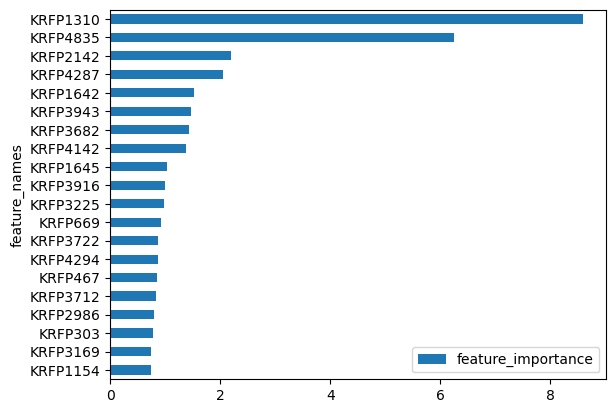

In [50]:
data[:20].sort_values(by=['feature_importance'], ascending=True).plot.barh(x='feature_names', y='feature_importance')

In [51]:
import shap

In [52]:
explainer = shap.Explainer(best_CatBR)

In [53]:
shap_values = explainer(descriptors_ws)

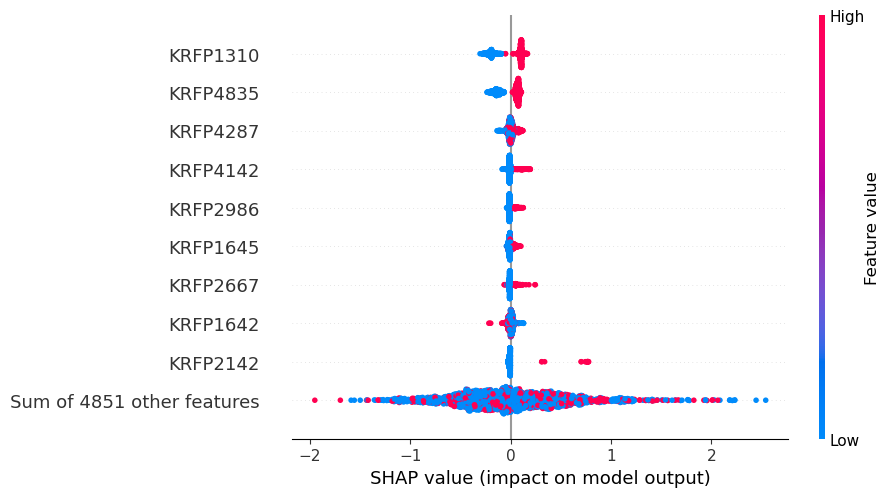

In [54]:
shap.plots.beeswarm(shap_values)

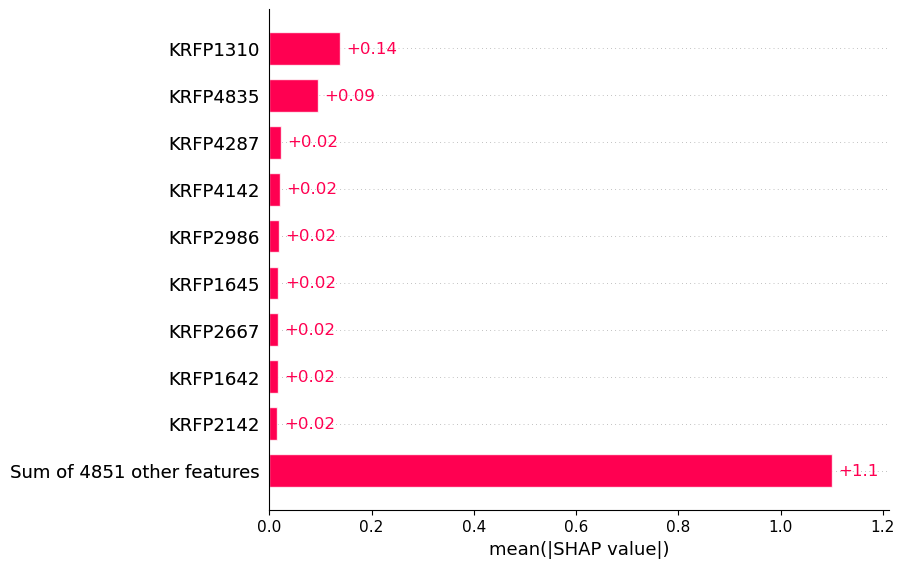

In [55]:
shap.plots.bar(shap_values)

# 11. Estimating applicability domain. Method - Euclidian distances, K=1

In [56]:
neighbors_k= pairwise_distances(x_tr, n_jobs=-1)
neighbors_k.sort(0)

In [57]:
df_tr=pd.DataFrame(neighbors_k)
df_tr

,0,1,2,3,4,5,6,7,8,9,...,2200,2201,2202,2203,2204,2205,2206,2207,2208,2209
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,6.244998,3.872983,2.828427,0.000000,3.000000,2.828427,3.000000,0.000000,3.000000,3.162278,...,1.000000,3.741657,5.567764,2.449490,6.000000,6.164414,0.000000,0.000000,3.316625,2.236068
2,6.324555,4.898980,3.872983,2.645751,3.000000,4.795832,3.162278,2.645751,4.123106,3.316625,...,2.000000,5.567764,5.656854,2.645751,6.403124,6.244998,1.414214,1.414214,4.123106,2.828427
3,6.633250,5.477226,3.872983,2.645751,3.464102,5.916080,3.162278,2.645751,4.358899,3.464102,...,2.449490,6.403124,5.744563,2.828427,6.480741,6.403124,1.732051,1.732051,4.358899,3.162278
4,6.708204,5.567764,4.242640,2.828427,3.605551,6.000000,3.162278,2.828427,4.582576,4.898980,...,3.605551,6.557438,5.830952,2.828427,7.211102,6.557438,1.732051,1.732051,4.472136,3.316625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.247449,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.041595,...,12.000000,12.569805,12.489996,12.206555,12.288206,12.529964,12.845233,12.845233,13.928389,13.638182
2206,12.288206,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.083046,...,12.000000,12.569805,12.489996,12.247449,12.328828,12.529964,12.845233,12.845233,13.928389,13.638182
2207,12.328828,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.124355,...,12.000000,12.569805,12.569805,12.369317,12.449900,12.609520,12.845233,12.845233,13.928389,13.638182
2208,12.328828,12.961481,13.190906,13.152946,13.190906,13.892444,13.304134,13.152946,13.711309,12.165525,...,12.000000,12.569805,12.609520,12.409674,12.489996,12.649111,12.845233,12.845233,13.928389,13.638182


In [79]:
similarity= neighbors_k

In [80]:
Dmean=np.mean(similarity[1,:])

In [81]:
round(Dmean, 2)

np.float32(2.69)

In [82]:
std=np.std(similarity[1,:])

In [83]:
round(std, 2)

np.float32(1.49)

In [84]:
model_AD_limit=Dmean+std*0.5
print(np.round(model_AD_limit, 2))

3.43


In [85]:
neighbors_k_ts= pairwise_distances(x_tr,Y=desc_ts, n_jobs=-1)
neighbors_k_ts.sort(0)

In [86]:
x_ts_AD=pd.DataFrame(neighbors_k_ts)
x_ts_AD

,0,1,2,3,4,5,6,7,8,9,...,543,544,545,546,547,548,549,550,551,552
0,4.242641,4.795832,3.000000,3.464102,2.645751,2.828427,2.828427,2.000000,4.242641,2.000000,...,4.242641,1.732051,2.828427,3.316625,2.645751,3.000000,3.000000,1.732051,2.828427,1.000000
1,4.242641,6.244998,3.741657,3.605551,2.828427,2.828427,3.316625,2.449490,4.242641,2.000000,...,4.358899,2.828427,3.464102,3.605551,2.645751,4.242641,3.162278,2.449490,3.872983,1.000000
2,4.358899,6.324555,4.000000,4.472136,2.828427,3.464102,3.872983,2.645751,4.472136,2.236068,...,4.472136,3.464102,3.464102,3.741657,2.828427,4.242641,3.162278,2.449490,4.123106,1.414214
3,4.358899,6.557439,4.123106,4.472136,3.316625,3.605551,3.872983,2.645751,4.582576,2.236068,...,4.690416,3.605551,3.605551,3.872983,3.000000,4.472136,3.316625,2.645751,4.242641,2.000000
4,4.898979,6.782330,4.795832,4.690416,3.741657,3.741657,4.000000,2.645751,4.898979,2.236068,...,4.795832,3.605551,3.605551,4.000000,3.162278,4.472136,3.316625,2.645751,4.358899,2.828427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,13.527749,12.288206,13.379088,12.247449,12.922848,13.152946,12.206556,13.674794,13.038405,13.711309,...,12.688578,12.041595,11.958261,12.328828,12.165525,12.369317,12.124356,12.124356,12.409674,12.845233
2206,13.527749,12.288206,13.379088,12.247449,12.922848,13.152946,12.247449,13.674794,13.038405,13.711309,...,12.688578,12.124356,11.958261,12.328828,12.165525,12.369317,12.124356,12.124356,12.409674,12.845233
2207,13.527749,12.288206,13.379088,12.328828,12.922848,13.152946,12.328828,13.674794,13.038405,13.711309,...,12.688578,12.124356,12.000000,12.449900,12.288206,12.449900,12.247449,12.247449,12.529964,13.000000
2208,13.527749,12.328828,13.379088,12.409674,13.000000,13.228757,12.409674,13.674794,13.038405,13.711309,...,12.767145,12.165525,12.083046,12.489996,12.328828,12.489996,12.288206,12.288206,12.569805,13.076697


In [87]:
similarity_ts= neighbors_k_ts
cpd_AD=similarity_ts[0,:]
cpd_value = np.round(cpd_AD, 3)
print(cpd_value)

[4.243 4.796 3.    3.464 2.646 2.828 2.828 2.    4.243 2.    6.164 1.414
 2.    5.916 3.    4.472 2.828 1.    1.732 4.583 0.    1.414 1.    2.
 2.236 2.828 2.646 1.    1.732 2.449 3.    4.899 2.    3.464 1.414 5.196
 3.317 4.583 5.916 1.732 5.    4.123 3.    0.    3.742 3.162 2.    3.162
 1.732 2.    2.449 2.    2.    3.464 3.    1.414 2.236 4.    0.    2.449
 2.236 2.449 2.    3.464 2.828 3.162 2.828 4.472 3.873 4.    2.828 2.236
 0.    1.732 2.828 0.    6.245 1.414 2.828 1.414 1.732 2.449 1.414 2.236
 4.583 2.449 5.385 1.414 0.    3.    3.464 2.828 3.162 2.828 3.    5.292
 4.123 3.606 0.    3.606 3.742 2.    1.    2.    2.    1.732 4.    5.099
 2.449 4.243 1.414 2.646 4.472 2.    0.    2.646 3.    3.317 2.    1.732
 1.    1.732 0.    4.123 0.    1.732 2.828 0.    3.    2.236 5.568 5.196
 4.123 6.856 2.    2.449 2.236 3.    2.    3.    1.732 3.317 1.414 1.732
 3.162 1.732 0.    4.359 1.732 2.449 0.    1.732 2.646 4.    3.317 3.
 7.416 3.606 2.449 2.646 2.449 2.    3.    1.414 2.646 1.

In [88]:
cpd_AD = np.where(cpd_value <= model_AD_limit, True, False)
print(cpd_AD)

[False False  True False  True  True  True  True False  True False  True
  True False  True False  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True False  True False  True False
  True False False  True False False  True  True False  True  True  True
  True  True  True  True  True False  True  True  True False  True  True
  True  True  True False  True  True  True False False False  True  True
  True  True  True  True False  True  True  True  True  True  True  True
 False  True False  True  True  True False  True  True  True  True False
 False False  True False False  True  True  True  True  True False False
  True False  True  True False  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True False False
 False False  True  True  True  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True False  True  True
 False False  True  True  True  True  True  True  T

In [89]:
print("Coverage = ", round(sum(cpd_AD) / len(cpd_AD),2))

Coverage =  0.72


In [90]:
print("Indices of substances included in AD = ", np.where(cpd_AD != 0)[0])

Indices of substances included in AD =  [  2   4   5   6   7   9  11  12  14  16  17  18  20  21  22  23  24  25
  26  27  28  29  30  32  34  36  39  42  43  45  46  47  48  49  50  51
  52  54  55  56  58  59  60  61  62  64  65  66  70  71  72  73  74  75
  77  78  79  80  81  82  83  85  87  88  89  91  92  93  94  98 101 102
 103 104 105 108 110 111 113 114 115 116 117 118 119 120 121 122 124 125
 126 127 128 129 134 135 136 137 138 139 140 141 142 143 144 145 146 148
 149 150 151 152 154 155 158 159 160 161 162 163 164 165 167 168 169 170
 171 172 173 175 176 177 178 181 182 183 185 186 188 191 194 195 200 201
 202 205 207 208 209 211 213 214 215 216 217 220 221 222 224 225 227 228
 229 230 231 232 233 234 235 237 239 240 241 242 243 245 246 247 250 251
 252 253 255 258 259 261 262 263 264 265 266 267 268 270 271 272 273 274
 275 276 278 279 280 282 283 286 288 289 290 291 292 293 294 296 298 299
 300 301 304 305 307 308 310 311 312 313 316 317 318 319 320 321 322 323
 324 326 32

In [91]:
out_Ad=list(np.where(cpd_AD == 0)[0])

# 12. Prediction only for molecules included in  AD

In [92]:
y_pred_GBR_ad=list(y_pred_GBR)

In [93]:
y_pred_GBR_ad[:] = [x for i,x in enumerate(y_pred_GBR_ad) if i not in out_Ad]

In [94]:
len(y_pred_GBR_ad)

398

In [95]:
y_ts_ad=list(y_ts)

In [96]:
y_ts_ad[:] = [x for i,x in enumerate(y_ts_ad) if i not in out_Ad]

In [97]:
len(y_ts_ad)

398

In [98]:
Q2_TS = round(r2_score(y_ts_ad, y_pred_GBR_ad), 2)
Q2_TS

0.64

In [99]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts_ad, y_pred_GBR_ad)), 2))
RMSE_TS

0.52

# SVM model building and validation

In [100]:
from sklearn.svm import SVR

In [101]:
param_grid = {"C": [10 ** i for i in range(0, 5)],
              "gamma": [10 ** i for i in range(-6, 0)]}

In [102]:
seed = 42
cv=KFold(n_splits=5, random_state=seed, shuffle=True)

In [103]:
svm = GridSearchCV(SVR(C=1.0, epsilon=0.2), param_grid, n_jobs=-1, cv=cv, verbose=1)

In [104]:
svm.fit(x_tr, y_tr)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,SVR(epsilon=0.2)
,param_grid,"{'C': [1, 10, ...], 'gamma': [1e-06, 1e-05, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [105]:
svm.best_params_
best_svm = svm.best_estimator_

In [106]:
svm.best_params_

{'C': 10, 'gamma': 0.01}

In [107]:
y_pred_ws_SVM = best_svm.predict(x_tr)

In [108]:
R2_WS = round(r2_score(y_tr, y_pred_ws_SVM), 2)
R2_WS

0.89

In [109]:
RMSE_WS=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_ws_SVM)), 2))
RMSE_WS

0.28

In [110]:
y_pred_CV_svm = cross_val_predict(best_svm, x_tr, y_tr, cv=cv)

In [111]:
Q2_CV = round(r2_score(y_tr, y_pred_CV_svm), 2)
Q2_CV

0.52

In [112]:
RMSE_CV=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_CV_svm)), 2))
RMSE_CV

0.59

#  Prediction for test set's molecules

In [113]:
x_ts = np.array(desc_ts, dtype=np.float32)
y_ts = np.array(y_ts, dtype=np.float32)

In [114]:
y_pred_svm = best_svm.predict(x_ts)

In [115]:
Q2_TS = round(r2_score(y_ts, y_pred_svm), 2)
Q2_TS

0.55

In [116]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts, y_pred_svm)), 2))
RMSE_TS

0.57

save the model to disk

In [117]:
pickle.dump(best_svm, open('Models/Padels/SVM_KlekotaRoth.pkl', 'wb'))

load the model from disk

In [118]:
best_svm = pickle.load(open('Models/Padels/SVM_KlekotaRoth.pkl', 'rb'))

# 11. Estimating applicability domain. Method - Euclidian distances, K=1

In [119]:
neighbors_k= pairwise_distances(x_tr, n_jobs=-1)
neighbors_k.sort(0)

In [120]:
df_tr=pd.DataFrame(neighbors_k)
df_tr

,0,1,2,3,4,5,6,7,8,9,...,2200,2201,2202,2203,2204,2205,2206,2207,2208,2209
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,6.244998,3.872983,2.828427,0.000000,3.000000,2.828427,3.000000,0.000000,3.000000,3.162278,...,1.000000,3.741657,5.567764,2.449490,6.000000,6.164414,0.000000,0.000000,3.316625,2.236068
2,6.324555,4.898980,3.872983,2.645751,3.000000,4.795832,3.162278,2.645751,4.123106,3.316625,...,2.000000,5.567764,5.656854,2.645751,6.403124,6.244998,1.414214,1.414214,4.123106,2.828427
3,6.633250,5.477226,3.872983,2.645751,3.464102,5.916080,3.162278,2.645751,4.358899,3.464102,...,2.449490,6.403124,5.744563,2.828427,6.480741,6.403124,1.732051,1.732051,4.358899,3.162278
4,6.708204,5.567764,4.242640,2.828427,3.605551,6.000000,3.162278,2.828427,4.582576,4.898980,...,3.605551,6.557438,5.830952,2.828427,7.211102,6.557438,1.732051,1.732051,4.472136,3.316625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.247449,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.041595,...,12.000000,12.569805,12.489996,12.206555,12.288206,12.529964,12.845233,12.845233,13.928389,13.638182
2206,12.288206,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.083046,...,12.000000,12.569805,12.489996,12.247449,12.328828,12.529964,12.845233,12.845233,13.928389,13.638182
2207,12.328828,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.124355,...,12.000000,12.569805,12.569805,12.369317,12.449900,12.609520,12.845233,12.845233,13.928389,13.638182
2208,12.328828,12.961481,13.190906,13.152946,13.190906,13.892444,13.304134,13.152946,13.711309,12.165525,...,12.000000,12.569805,12.609520,12.409674,12.489996,12.649111,12.845233,12.845233,13.928389,13.638182


In [121]:
similarity= neighbors_k

In [122]:
Dmean=np.mean(similarity[1,:])

In [123]:
round(Dmean, 2)

np.float32(2.69)

In [124]:
std=np.std(similarity[1,:])

In [125]:
round(std, 2)

np.float32(1.49)

In [126]:
model_AD_limit=Dmean+std*0.5
print(np.round(model_AD_limit, 2))

3.43


In [127]:
neighbors_k_ts= pairwise_distances(x_tr,Y=x_ts, n_jobs=-1)
neighbors_k_ts.sort(0)

In [128]:
x_ts_AD=pd.DataFrame(neighbors_k_ts)
x_ts_AD

,0,1,2,3,4,5,6,7,8,9,...,543,544,545,546,547,548,549,550,551,552
0,4.242640,4.795832,3.000000,3.464102,2.645751,2.828427,2.828427,2.000000,4.242640,2.000000,...,4.242640,1.732051,2.828427,3.316625,2.645751,3.000000,3.000000,1.732051,2.828427,1.000000
1,4.242640,6.244998,3.741657,3.605551,2.828427,2.828427,3.316625,2.449490,4.242640,2.000000,...,4.358899,2.828427,3.464102,3.605551,2.645751,4.242640,3.162278,2.449490,3.872983,1.000000
2,4.358899,6.324555,4.000000,4.472136,2.828427,3.464102,3.872983,2.645751,4.472136,2.236068,...,4.472136,3.464102,3.464102,3.741657,2.828427,4.242640,3.162278,2.449490,4.123106,1.414214
3,4.358899,6.557438,4.123106,4.472136,3.316625,3.605551,3.872983,2.645751,4.582576,2.236068,...,4.690416,3.605551,3.605551,3.872983,3.000000,4.472136,3.316625,2.645751,4.242640,2.000000
4,4.898980,6.782330,4.795832,4.690416,3.741657,3.741657,4.000000,2.645751,4.898980,2.236068,...,4.795832,3.605551,3.605551,4.000000,3.162278,4.472136,3.316625,2.645751,4.358899,2.828427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,13.527749,12.288206,13.379088,12.247449,12.922848,13.152946,12.206555,13.674794,13.038404,13.711309,...,12.688578,12.041595,11.958261,12.328828,12.165525,12.369317,12.124355,12.124355,12.409674,12.845233
2206,13.527749,12.288206,13.379088,12.247449,12.922848,13.152946,12.247449,13.674794,13.038404,13.711309,...,12.688578,12.124355,11.958261,12.328828,12.165525,12.369317,12.124355,12.124355,12.409674,12.845233
2207,13.527749,12.288206,13.379088,12.328828,12.922848,13.152946,12.328828,13.674794,13.038404,13.711309,...,12.688578,12.124355,12.000000,12.449900,12.288206,12.449900,12.247449,12.247449,12.529964,13.000000
2208,13.527749,12.328828,13.379088,12.409674,13.000000,13.228757,12.409674,13.674794,13.038404,13.711309,...,12.767145,12.165525,12.083046,12.489996,12.328828,12.489996,12.288206,12.288206,12.569805,13.076696


In [129]:
similarity_ts= neighbors_k_ts
cpd_AD=similarity_ts[0,:]
cpd_value = np.round(cpd_AD, 3)
print(cpd_value)

[4.243 4.796 3.    3.464 2.646 2.828 2.828 2.    4.243 2.    6.164 1.414
 2.    5.916 3.    4.472 2.828 1.    1.732 4.583 0.    1.414 1.    2.
 2.236 2.828 2.646 1.    1.732 2.449 3.    4.899 2.    3.464 1.414 5.196
 3.317 4.583 5.916 1.732 5.    4.123 3.    0.    3.742 3.162 2.    3.162
 1.732 2.    2.449 2.    2.    3.464 3.    1.414 2.236 4.    0.    2.449
 2.236 2.449 2.    3.464 2.828 3.162 2.828 4.472 3.873 4.    2.828 2.236
 0.    1.732 2.828 0.    6.245 1.414 2.828 1.414 1.732 2.449 1.414 2.236
 4.583 2.449 5.385 1.414 0.    3.    3.464 2.828 3.162 2.828 3.    5.292
 4.123 3.606 0.    3.606 3.742 2.    1.    2.    2.    1.732 4.    5.099
 2.449 4.243 1.414 2.646 4.472 2.    0.    2.646 3.    3.317 2.    1.732
 1.    1.732 0.    4.123 0.    1.732 2.828 0.    3.    2.236 5.568 5.196
 4.123 6.856 2.    2.449 2.236 3.    2.    3.    1.732 3.317 1.414 1.732
 3.162 1.732 0.    4.359 1.732 2.449 0.    1.732 2.646 4.    3.317 3.
 7.416 3.606 2.449 2.646 2.449 2.    3.    1.414 2.646 1.

In [130]:
cpd_AD = np.where(cpd_value <= model_AD_limit, True, False)
print(cpd_AD)

[False False  True False  True  True  True  True False  True False  True
  True False  True False  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True False  True False  True False
  True False False  True False False  True  True False  True  True  True
  True  True  True  True  True False  True  True  True False  True  True
  True  True  True False  True  True  True False False False  True  True
  True  True  True  True False  True  True  True  True  True  True  True
 False  True False  True  True  True False  True  True  True  True False
 False False  True False False  True  True  True  True  True False False
  True False  True  True False  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True False False
 False False  True  True  True  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True False  True  True
 False False  True  True  True  True  True  True  T

In [131]:
print("Coverage = ", round(sum(cpd_AD) / len(cpd_AD), 2))

Coverage =  0.72


In [132]:
print("Indices of substances included in AD = ", np.where(cpd_AD != 0)[0])

Indices of substances included in AD =  [  2   4   5   6   7   9  11  12  14  16  17  18  20  21  22  23  24  25
  26  27  28  29  30  32  34  36  39  42  43  45  46  47  48  49  50  51
  52  54  55  56  58  59  60  61  62  64  65  66  70  71  72  73  74  75
  77  78  79  80  81  82  83  85  87  88  89  91  92  93  94  98 101 102
 103 104 105 108 110 111 113 114 115 116 117 118 119 120 121 122 124 125
 126 127 128 129 134 135 136 137 138 139 140 141 142 143 144 145 146 148
 149 150 151 152 154 155 158 159 160 161 162 163 164 165 167 168 169 170
 171 172 173 175 176 177 178 181 182 183 185 186 188 191 194 195 200 201
 202 205 207 208 209 211 213 214 215 216 217 220 221 222 224 225 227 228
 229 230 231 232 233 234 235 237 239 240 241 242 243 245 246 247 250 251
 252 253 255 258 259 261 262 263 264 265 266 267 268 270 271 272 273 274
 275 276 278 279 280 282 283 286 288 289 290 291 292 293 294 296 298 299
 300 301 304 305 307 308 310 311 312 313 316 317 318 319 320 321 322 323
 324 326 32

In [133]:
out_Ad=list(np.where(cpd_AD == 0)[0])

# 12. Prediction only for molecules included in  AD

In [134]:
y_pred_svm_ad=list(y_pred_svm)

In [135]:
y_pred_svm_ad[:] = [x for i,x in enumerate(y_pred_svm_ad) if i not in out_Ad]

In [136]:
len(y_pred_svm_ad)

398

In [137]:
y_ts_ad=list(y_ts)

In [138]:
y_ts_ad[:] = [x for i,x in enumerate(y_ts_ad) if i not in out_Ad]

In [139]:
len(y_ts_ad)

398

In [140]:
Q2_TS = round(r2_score(y_ts_ad, y_pred_svm_ad), 2)
Q2_TS

0.61

In [141]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts_ad, y_pred_svm_ad)), 2))
RMSE_TS

0.54

# Multi-layer Perceptron regressor

In [33]:
from sklearn.neural_network import MLPRegressor

In [34]:
param_grid ={"hidden_layer_sizes": [(100, 100, 100), (10, 10, 10),(50,)], "activation": ["tanh", "relu"], "solver": ["lbfgs", "sgd", "adam"], "alpha": [0.00005,0.0005], 'max_iter': [1000, 2000]}

In [35]:
m = GridSearchCV(MLPRegressor(), param_grid, n_jobs=-1, cv=cv, verbose=1)

In [36]:
m.fit(x_tr, y_tr)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,MLPRegressor()
,param_grid,"{'activation': ['tanh', 'relu'], 'alpha': [5e-05, 0.0005], 'hidden_layer_sizes': [(100, ...), (10, ...), ...], 'max_iter': [1000, 2000], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [37]:
best_MLPR = m.best_estimator_

In [38]:
y_pred_ws_best_MLPR = best_MLPR.predict(x_tr)

In [39]:
R2_WS = round(r2_score(y_tr, y_pred_ws_best_MLPR), 2)
R2_WS

0.94

In [40]:
RMSE_WS=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_ws_best_MLPR)), 2))
RMSE_WS

0.21

In [41]:
y_pred_CV_MLPR = cross_val_predict(best_MLPR, x_tr, y_tr, cv=cv)

In [42]:
Q2_CV = round(r2_score(y_tr, y_pred_CV_MLPR), 2)
Q2_CV

0.41

In [43]:
RMSE_CV=round(np.sqrt(mean_squared_error(y_tr, y_pred_CV_MLPR)), 2)
RMSE_CV

np.float64(0.65)

# Prediction for test set's molecules

In [44]:
y_pred_MLPR = best_MLPR.predict(x_ts)

In [45]:
Q2_TS = round(r2_score(y_ts, y_pred_MLPR), 2)
Q2_TS

0.48

In [46]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts, y_pred_MLPR)), 2))
RMSE_TS

0.62

save the model to disk

In [48]:
pickle.dump(best_MLPR, open('models/Padels/MLPR_KlekotaRoth.pkl', 'wb'))

load the model from disk

In [ ]:
best_MLPR = pickle.load(open('models/Padels/MLPR_KlekotaRoth.pkl', 'rb'))

#  Estimating applicability domain. Method - Euclidian distances, K=1

In [49]:
neighbors_k= pairwise_distances(x_tr, n_jobs=-1)
neighbors_k.sort(0)

In [50]:
df_tr=pd.DataFrame(neighbors_k)
df_tr

,0,1,2,3,4,5,6,7,8,9,...,2200,2201,2202,2203,2204,2205,2206,2207,2208,2209
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,6.244998,3.872983,2.828427,0.000000,3.000000,2.828427,3.000000,0.000000,3.000000,3.162278,...,1.000000,3.741657,5.567764,2.449490,6.000000,6.164414,0.000000,0.000000,3.316625,2.236068
2,6.324555,4.898980,3.872983,2.645751,3.000000,4.795832,3.162278,2.645751,4.123106,3.316625,...,2.000000,5.567764,5.656854,2.645751,6.403124,6.244998,1.414214,1.414214,4.123106,2.828427
3,6.633250,5.477226,3.872983,2.645751,3.464102,5.916080,3.162278,2.645751,4.358899,3.464102,...,2.449490,6.403124,5.744563,2.828427,6.480741,6.403124,1.732051,1.732051,4.358899,3.162278
4,6.708204,5.567764,4.242640,2.828427,3.605551,6.000000,3.162278,2.828427,4.582576,4.898980,...,3.605551,6.557438,5.830952,2.828427,7.211102,6.557438,1.732051,1.732051,4.472136,3.316625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.247449,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.041595,...,12.000000,12.569805,12.489996,12.206555,12.288206,12.529964,12.845233,12.845233,13.928389,13.638182
2206,12.288206,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.083046,...,12.000000,12.569805,12.489996,12.247449,12.328828,12.529964,12.845233,12.845233,13.928389,13.638182
2207,12.328828,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.124355,...,12.000000,12.569805,12.569805,12.369317,12.449900,12.609520,12.845233,12.845233,13.928389,13.638182
2208,12.328828,12.961481,13.190906,13.152946,13.190906,13.892444,13.304134,13.152946,13.711309,12.165525,...,12.000000,12.569805,12.609520,12.409674,12.489996,12.649111,12.845233,12.845233,13.928389,13.638182


In [51]:
similarity= neighbors_k

In [52]:
Dmean=np.mean(similarity[1,:])

In [53]:
round(Dmean, 2)

np.float32(2.69)

In [54]:
std=np.std(similarity[1,:])

In [55]:
round(std, 2)

np.float32(1.49)

In [56]:
model_AD_limit=Dmean+std*0.5
print(np.round(model_AD_limit, 2))

3.43


In [57]:
neighbors_k_ts= pairwise_distances(x_tr,Y=x_ts, n_jobs=-1)
neighbors_k_ts.sort(0)

In [58]:
x_ts_AD=pd.DataFrame(neighbors_k_ts)
x_ts_AD

,0,1,2,3,4,5,6,7,8,9,...,543,544,545,546,547,548,549,550,551,552
0,4.242641,4.795832,3.000000,3.464102,2.645751,2.828427,2.828427,2.000000,4.242641,2.000000,...,4.242641,1.732051,2.828427,3.316625,2.645751,3.000000,3.000000,1.732051,2.828427,1.000000
1,4.242641,6.244998,3.741657,3.605551,2.828427,2.828427,3.316625,2.449490,4.242641,2.000000,...,4.358899,2.828427,3.464102,3.605551,2.645751,4.242641,3.162278,2.449490,3.872983,1.000000
2,4.358899,6.324555,4.000000,4.472136,2.828427,3.464102,3.872983,2.645751,4.472136,2.236068,...,4.472136,3.464102,3.464102,3.741657,2.828427,4.242641,3.162278,2.449490,4.123106,1.414214
3,4.358899,6.557439,4.123106,4.472136,3.316625,3.605551,3.872983,2.645751,4.582576,2.236068,...,4.690416,3.605551,3.605551,3.872983,3.000000,4.472136,3.316625,2.645751,4.242641,2.000000
4,4.898979,6.782330,4.795832,4.690416,3.741657,3.741657,4.000000,2.645751,4.898979,2.236068,...,4.795832,3.605551,3.605551,4.000000,3.162278,4.472136,3.316625,2.645751,4.358899,2.828427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,13.527749,12.288206,13.379088,12.247449,12.922848,13.152946,12.206556,13.674794,13.038405,13.711309,...,12.688578,12.041595,11.958261,12.328828,12.165525,12.369317,12.124356,12.124356,12.409674,12.845233
2206,13.527749,12.288206,13.379088,12.247449,12.922848,13.152946,12.247449,13.674794,13.038405,13.711309,...,12.688578,12.124356,11.958261,12.328828,12.165525,12.369317,12.124356,12.124356,12.409674,12.845233
2207,13.527749,12.288206,13.379088,12.328828,12.922848,13.152946,12.328828,13.674794,13.038405,13.711309,...,12.688578,12.124356,12.000000,12.449900,12.288206,12.449900,12.247449,12.247449,12.529964,13.000000
2208,13.527749,12.328828,13.379088,12.409674,13.000000,13.228757,12.409674,13.674794,13.038405,13.711309,...,12.767145,12.165525,12.083046,12.489996,12.328828,12.489996,12.288206,12.288206,12.569805,13.076697


In [59]:
similarity_ts= neighbors_k_ts
cpd_AD=similarity_ts[0,:]
cpd_value = np.round(cpd_AD, 3)
print(cpd_value)

[4.243 4.796 3.    3.464 2.646 2.828 2.828 2.    4.243 2.    6.164 1.414
 2.    5.916 3.    4.472 2.828 1.    1.732 4.583 0.    1.414 1.    2.
 2.236 2.828 2.646 1.    1.732 2.449 3.    4.899 2.    3.464 1.414 5.196
 3.317 4.583 5.916 1.732 5.    4.123 3.    0.    3.742 3.162 2.    3.162
 1.732 2.    2.449 2.    2.    3.464 3.    1.414 2.236 4.    0.    2.449
 2.236 2.449 2.    3.464 2.828 3.162 2.828 4.472 3.873 4.    2.828 2.236
 0.    1.732 2.828 0.    6.245 1.414 2.828 1.414 1.732 2.449 1.414 2.236
 4.583 2.449 5.385 1.414 0.    3.    3.464 2.828 3.162 2.828 3.    5.292
 4.123 3.606 0.    3.606 3.742 2.    1.    2.    2.    1.732 4.    5.099
 2.449 4.243 1.414 2.646 4.472 2.    0.    2.646 3.    3.317 2.    1.732
 1.    1.732 0.    4.123 0.    1.732 2.828 0.    3.    2.236 5.568 5.196
 4.123 6.856 2.    2.449 2.236 3.    2.    3.    1.732 3.317 1.414 1.732
 3.162 1.732 0.    4.359 1.732 2.449 0.    1.732 2.646 4.    3.317 3.
 7.416 3.606 2.449 2.646 2.449 2.    3.    1.414 2.646 1.

In [60]:
cpd_AD = np.where(cpd_value <= model_AD_limit, True, False)
print(cpd_AD)

[False False  True False  True  True  True  True False  True False  True
  True False  True False  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True False  True False  True False
  True False False  True False False  True  True False  True  True  True
  True  True  True  True  True False  True  True  True False  True  True
  True  True  True False  True  True  True False False False  True  True
  True  True  True  True False  True  True  True  True  True  True  True
 False  True False  True  True  True False  True  True  True  True False
 False False  True False False  True  True  True  True  True False False
  True False  True  True False  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True False False
 False False  True  True  True  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True False  True  True
 False False  True  True  True  True  True  True  T

In [61]:
print("Coverage = ", round(sum(cpd_AD) / len(cpd_AD), 2))

Coverage =  0.72


In [62]:
print("Indices of substances included in AD = ", np.where(cpd_AD != 0)[0])

Indices of substances included in AD =  [  2   4   5   6   7   9  11  12  14  16  17  18  20  21  22  23  24  25
  26  27  28  29  30  32  34  36  39  42  43  45  46  47  48  49  50  51
  52  54  55  56  58  59  60  61  62  64  65  66  70  71  72  73  74  75
  77  78  79  80  81  82  83  85  87  88  89  91  92  93  94  98 101 102
 103 104 105 108 110 111 113 114 115 116 117 118 119 120 121 122 124 125
 126 127 128 129 134 135 136 137 138 139 140 141 142 143 144 145 146 148
 149 150 151 152 154 155 158 159 160 161 162 163 164 165 167 168 169 170
 171 172 173 175 176 177 178 181 182 183 185 186 188 191 194 195 200 201
 202 205 207 208 209 211 213 214 215 216 217 220 221 222 224 225 227 228
 229 230 231 232 233 234 235 237 239 240 241 242 243 245 246 247 250 251
 252 253 255 258 259 261 262 263 264 265 266 267 268 270 271 272 273 274
 275 276 278 279 280 282 283 286 288 289 290 291 292 293 294 296 298 299
 300 301 304 305 307 308 310 311 312 313 316 317 318 319 320 321 322 323
 324 326 32

In [63]:
out_Ad=list(np.where(cpd_AD == 0)[0])

# Prediction only for molecules included in  AD

In [64]:
y_pred_MLPR_ad=list(y_pred_MLPR)

In [65]:
y_pred_MLPR_ad[:] = [x for i,x in enumerate(y_pred_MLPR_ad) if i not in out_Ad]

In [66]:
len(y_pred_MLPR_ad)

398

In [67]:
y_ts_ad=list(y_ts)

In [68]:
y_ts_ad[:] = [x for i,x in enumerate(y_ts_ad) if i not in out_Ad]

In [69]:
len(y_ts_ad)

398

In [70]:
Q2_TS = round(r2_score(y_ts_ad, y_pred_MLPR_ad), 2)
Q2_TS

0.58

In [71]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts_ad, y_pred_MLPR_ad)), 2))
RMSE_TS

0.56

# k-nearest neighbors

In [72]:
k_range = list(range(1, 31))
param_grid = dict(n_neighbors=k_range)

In [73]:
m = GridSearchCV(KNeighborsRegressor(), param_grid, n_jobs=-1, cv=cv, verbose=1)

In [74]:
m.fit(x_tr, y_tr)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [1, 2, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [75]:
best_kNN = m.best_estimator_

In [76]:
m.best_params_

{'n_neighbors': 3}

In [77]:
y_pred_ws_kNN = best_kNN.predict(x_tr)

In [78]:
R2_WS = round(r2_score(y_tr, y_pred_ws_kNN), 2)
R2_WS

0.77

In [79]:
RMSE_WS=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_ws_kNN)), 2))
RMSE_WS

0.41

In [80]:
y_pred_CV_kNN = cross_val_predict(best_kNN, x_tr, y_tr, cv=cv)

In [81]:
y_pred_CV_kNN

array([4.5333333, 5.73     , 4.39     , ..., 7.976667 , 6.263334 ,
       7.65     ], shape=(2210,), dtype=float32)

In [82]:
Q2_CV = round(r2_score(y_tr, y_pred_CV_kNN), 2)
Q2_CV

0.46

In [83]:
RMSE_CV=float(round(np.sqrt(mean_squared_error(y_tr, y_pred_CV_kNN)), 2))
RMSE_CV

0.62

# 9. Prediction for test set's molecules

In [84]:
y_pred_kNN = best_kNN.predict(x_ts)

In [85]:
Q2_TS = round(r2_score(y_ts, y_pred_kNN), 2)
Q2_TS

0.47

In [86]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts, y_pred_kNN)), 2))
RMSE_TS

0.62

# save the model to disk

In [87]:
pickle.dump(best_kNN, open('models/Padels/KlekotaRoth_kNN.pkl', 'wb'))

# load the model from disk

In [88]:
best_kNN = pickle.load(open('models/Padels/KlekotaRoth_kNN.pkl', 'rb'))

#  Estimating applicability domain. Method - Euclidian distances, K=1

In [89]:
neighbors_k= pairwise_distances(x_tr, n_jobs=-1)
neighbors_k.sort(0)

In [90]:
df_tr=pd.DataFrame(neighbors_k)
df_tr

,0,1,2,3,4,5,6,7,8,9,...,2200,2201,2202,2203,2204,2205,2206,2207,2208,2209
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,6.244998,3.872983,2.828427,0.000000,3.000000,2.828427,3.000000,0.000000,3.000000,3.162278,...,1.000000,3.741657,5.567764,2.449490,6.000000,6.164414,0.000000,0.000000,3.316625,2.236068
2,6.324555,4.898980,3.872983,2.645751,3.000000,4.795832,3.162278,2.645751,4.123106,3.316625,...,2.000000,5.567764,5.656854,2.645751,6.403124,6.244998,1.414214,1.414214,4.123106,2.828427
3,6.633250,5.477226,3.872983,2.645751,3.464102,5.916080,3.162278,2.645751,4.358899,3.464102,...,2.449490,6.403124,5.744563,2.828427,6.480741,6.403124,1.732051,1.732051,4.358899,3.162278
4,6.708204,5.567764,4.242640,2.828427,3.605551,6.000000,3.162278,2.828427,4.582576,4.898980,...,3.605551,6.557438,5.830952,2.828427,7.211102,6.557438,1.732051,1.732051,4.472136,3.316625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,12.247449,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.041595,...,12.000000,12.569805,12.489996,12.206555,12.288206,12.529964,12.845233,12.845233,13.928389,13.638182
2206,12.288206,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.083046,...,12.000000,12.569805,12.489996,12.247449,12.328828,12.529964,12.845233,12.845233,13.928389,13.638182
2207,12.328828,12.961481,13.114877,13.076696,13.114877,13.820275,13.228757,13.076696,13.711309,12.124355,...,12.000000,12.569805,12.569805,12.369317,12.449900,12.609520,12.845233,12.845233,13.928389,13.638182
2208,12.328828,12.961481,13.190906,13.152946,13.190906,13.892444,13.304134,13.152946,13.711309,12.165525,...,12.000000,12.569805,12.609520,12.409674,12.489996,12.649111,12.845233,12.845233,13.928389,13.638182


In [91]:
similarity= neighbors_k

In [92]:
Dmean=np.mean(similarity[1,:])

In [93]:
round(Dmean, 2)

np.float32(2.69)

In [94]:
std=np.std(similarity[1,:])

In [95]:
round(std, 2)

np.float32(1.49)

In [96]:
model_AD_limit=Dmean+std*0.5
print(np.round(model_AD_limit, 2))

3.43


In [97]:
neighbors_k_ts= pairwise_distances(x_tr,Y=desc_ts, n_jobs=-1)
neighbors_k_ts.sort(0)

In [98]:
x_ts_AD=pd.DataFrame(neighbors_k_ts)
x_ts_AD

,0,1,2,3,4,5,6,7,8,9,...,543,544,545,546,547,548,549,550,551,552
0,4.242641,4.795832,3.000000,3.464102,2.645751,2.828427,2.828427,2.000000,4.242641,2.000000,...,4.242641,1.732051,2.828427,3.316625,2.645751,3.000000,3.000000,1.732051,2.828427,1.000000
1,4.242641,6.244998,3.741657,3.605551,2.828427,2.828427,3.316625,2.449490,4.242641,2.000000,...,4.358899,2.828427,3.464102,3.605551,2.645751,4.242641,3.162278,2.449490,3.872983,1.000000
2,4.358899,6.324555,4.000000,4.472136,2.828427,3.464102,3.872983,2.645751,4.472136,2.236068,...,4.472136,3.464102,3.464102,3.741657,2.828427,4.242641,3.162278,2.449490,4.123106,1.414214
3,4.358899,6.557439,4.123106,4.472136,3.316625,3.605551,3.872983,2.645751,4.582576,2.236068,...,4.690416,3.605551,3.605551,3.872983,3.000000,4.472136,3.316625,2.645751,4.242641,2.000000
4,4.898979,6.782330,4.795832,4.690416,3.741657,3.741657,4.000000,2.645751,4.898979,2.236068,...,4.795832,3.605551,3.605551,4.000000,3.162278,4.472136,3.316625,2.645751,4.358899,2.828427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,13.527749,12.288206,13.379088,12.247449,12.922848,13.152946,12.206556,13.674794,13.038405,13.711309,...,12.688578,12.041595,11.958261,12.328828,12.165525,12.369317,12.124356,12.124356,12.409674,12.845233
2206,13.527749,12.288206,13.379088,12.247449,12.922848,13.152946,12.247449,13.674794,13.038405,13.711309,...,12.688578,12.124356,11.958261,12.328828,12.165525,12.369317,12.124356,12.124356,12.409674,12.845233
2207,13.527749,12.288206,13.379088,12.328828,12.922848,13.152946,12.328828,13.674794,13.038405,13.711309,...,12.688578,12.124356,12.000000,12.449900,12.288206,12.449900,12.247449,12.247449,12.529964,13.000000
2208,13.527749,12.328828,13.379088,12.409674,13.000000,13.228757,12.409674,13.674794,13.038405,13.711309,...,12.767145,12.165525,12.083046,12.489996,12.328828,12.489996,12.288206,12.288206,12.569805,13.076697


In [99]:
similarity_ts= neighbors_k_ts
cpd_AD=similarity_ts[0,:]
cpd_value = np.round(cpd_AD, 3)
print(cpd_value)

[4.243 4.796 3.    3.464 2.646 2.828 2.828 2.    4.243 2.    6.164 1.414
 2.    5.916 3.    4.472 2.828 1.    1.732 4.583 0.    1.414 1.    2.
 2.236 2.828 2.646 1.    1.732 2.449 3.    4.899 2.    3.464 1.414 5.196
 3.317 4.583 5.916 1.732 5.    4.123 3.    0.    3.742 3.162 2.    3.162
 1.732 2.    2.449 2.    2.    3.464 3.    1.414 2.236 4.    0.    2.449
 2.236 2.449 2.    3.464 2.828 3.162 2.828 4.472 3.873 4.    2.828 2.236
 0.    1.732 2.828 0.    6.245 1.414 2.828 1.414 1.732 2.449 1.414 2.236
 4.583 2.449 5.385 1.414 0.    3.    3.464 2.828 3.162 2.828 3.    5.292
 4.123 3.606 0.    3.606 3.742 2.    1.    2.    2.    1.732 4.    5.099
 2.449 4.243 1.414 2.646 4.472 2.    0.    2.646 3.    3.317 2.    1.732
 1.    1.732 0.    4.123 0.    1.732 2.828 0.    3.    2.236 5.568 5.196
 4.123 6.856 2.    2.449 2.236 3.    2.    3.    1.732 3.317 1.414 1.732
 3.162 1.732 0.    4.359 1.732 2.449 0.    1.732 2.646 4.    3.317 3.
 7.416 3.606 2.449 2.646 2.449 2.    3.    1.414 2.646 1.

In [100]:
cpd_AD = np.where(cpd_value <= model_AD_limit, True, False)
print(cpd_AD)

[False False  True False  True  True  True  True False  True False  True
  True False  True False  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True False  True False  True False
  True False False  True False False  True  True False  True  True  True
  True  True  True  True  True False  True  True  True False  True  True
  True  True  True False  True  True  True False False False  True  True
  True  True  True  True False  True  True  True  True  True  True  True
 False  True False  True  True  True False  True  True  True  True False
 False False  True False False  True  True  True  True  True False False
  True False  True  True False  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True False False
 False False  True  True  True  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True False  True  True
 False False  True  True  True  True  True  True  T

In [101]:
print("Coverage = ", round(sum(cpd_AD) / len(cpd_AD), 2))

Coverage =  0.72


In [102]:
print("Indices of substances included in AD = ", np.where(cpd_AD != 0)[0])

Indices of substances included in AD =  [  2   4   5   6   7   9  11  12  14  16  17  18  20  21  22  23  24  25
  26  27  28  29  30  32  34  36  39  42  43  45  46  47  48  49  50  51
  52  54  55  56  58  59  60  61  62  64  65  66  70  71  72  73  74  75
  77  78  79  80  81  82  83  85  87  88  89  91  92  93  94  98 101 102
 103 104 105 108 110 111 113 114 115 116 117 118 119 120 121 122 124 125
 126 127 128 129 134 135 136 137 138 139 140 141 142 143 144 145 146 148
 149 150 151 152 154 155 158 159 160 161 162 163 164 165 167 168 169 170
 171 172 173 175 176 177 178 181 182 183 185 186 188 191 194 195 200 201
 202 205 207 208 209 211 213 214 215 216 217 220 221 222 224 225 227 228
 229 230 231 232 233 234 235 237 239 240 241 242 243 245 246 247 250 251
 252 253 255 258 259 261 262 263 264 265 266 267 268 270 271 272 273 274
 275 276 278 279 280 282 283 286 288 289 290 291 292 293 294 296 298 299
 300 301 304 305 307 308 310 311 312 313 316 317 318 319 320 321 322 323
 324 326 32

In [103]:
out_Ad=list(np.where(cpd_AD == 0)[0])

# Prediction only for molecules included in  AD

In [104]:
y_pred_kNN_ad=list(y_pred_kNN)

In [105]:
y_pred_kNN_ad[:] = [x for i,x in enumerate(y_pred_kNN_ad) if i not in out_Ad]

In [106]:
len(y_pred_kNN_ad)

398

In [107]:
y_ts_ad=list(y_ts)

In [108]:
y_ts_ad[:] = [x for i,x in enumerate(y_ts_ad) if i not in out_Ad]

In [109]:
len(y_ts_ad)

398

In [110]:
Q2_TS = round(r2_score(y_ts_ad, y_pred_kNN_ad), 2)
Q2_TS

0.55

In [111]:
RMSE_TS=float(round(np.sqrt(mean_squared_error(y_ts_ad, y_pred_kNN_ad)), 2))
RMSE_TS

0.58